# DGFF — End-to-End Low-Light Enhancement with Detection-Guided Feature Feedback

**Single-notebook implementation** of the full pipeline:
- `LOLDataset` — paired low/high dataloader
- `LLEN` — U-Net encoder-decoder with DGFF injection points
- `DGFFModule` — YOLOv8 backbone + gated adapters (v2 with sigmoid gate)
- `PerceptualLoss` + `DetectionFeatureLoss` — composite training objective
- Training loop with λ_det curriculum
- Validation (PSNR / SSIM)
- Results visualisation

**Dataset**: LOL (485 train / 15 val)  
**Detector**: YOLOv8n (backbone frozen, adapters trained)  
**Loss**: L1 + λ_perc·L_perc + λ_det·L_det (ramped)

---
## 0 — Imports & Config

In [1]:
import os
import random
import time
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as T
import torchvision.transforms.functional as TF
import torchvision.models as models

from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

from ultralytics import YOLO

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = (
    torch.device('mps')  if torch.backends.mps.is_available() else
    torch.device('cuda') if torch.cuda.is_available()         else
    torch.device('cpu')
)
print(f"Device : {DEVICE}")

# ── Config — edit these paths / hyperparameters ───────────────────────────────
CFG = dict(
    # Data
    lol_root      = './LOL',          # path to LOL dataset root
    crop_size     = 256,              # training crop size

    # Model
    base_ch       = 32,               # LLEN base channels (32 → 32/64/128/256)
    yolo_weights  = 'yolov8n.pt',     # YOLOv8n weights (auto-download)

    # Training
    epochs        = 200,              # total epochs (was 3 for test)
    batch_size    = 4,                # images per batch (reduce to 2 if OOM)
    lr            = 1e-4,             # learning rate
    lambda_perc   = 0.1,              # perceptual loss weight
    lambda_det    = 0.5,              # max detection loss weight (ramped from 0)
    val_every     = 5,                # validate every N epochs
    num_workers   = 0,                # set 0 for Jupyter on Mac/Windows

    # Paths
    ckpt_dir      = './checkpoints',  # where to save best.pt and epoch_*.pt
)

Path(CFG['ckpt_dir']).mkdir(parents=True, exist_ok=True)
print("Config OK")

Device : mps
Config OK


---
## 1 — Dataset

In [2]:
class LOLDataset(Dataset):
    """
    Paired (low-light, normal-light) loader for the LOL dataset.

    LOL structure:
        LOL/
        ├── our485/low/   our485/high/   (485 train pairs)
        └── eval15/low/   eval15/high/   (15 val pairs)

    Download: https://drive.google.com/file/d/157bjO1_cFoSJ2FapgwwPM4I2beZlYXoO
    """
    SPLIT_DIRS = {'train': 'our485', 'val': 'eval15'}
    _IMG_EXTS  = {'.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'}

    def __init__(self, root, split='train', crop_size=256, augment=True):
        assert split in self.SPLIT_DIRS
        self.crop_size = crop_size
        self.augment   = augment and (split == 'train')

        base          = Path(root) / self.SPLIT_DIRS[split]
        self.low_dir  = base / 'low'
        self.high_dir = base / 'high'

        for d in (self.low_dir, self.high_dir):
            if not d.is_dir():
                raise FileNotFoundError(f"Not found: {d}")

        self.filenames = sorted(
            f for f in os.listdir(self.low_dir)
            if Path(f).suffix.lower() in self._IMG_EXTS
        )
        missing = [f for f in self.filenames if not (self.high_dir / f).exists()]
        if missing:
            raise FileNotFoundError(f"Missing high images: {missing[:3]}")

        self.to_tensor = T.ToTensor()

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        fname    = self.filenames[idx]
        low_img  = Image.open(self.low_dir  / fname).convert('RGB')
        high_img = Image.open(self.high_dir / fname).convert('RGB')

        if self.crop_size is not None:
            low_img, high_img = self._paired_crop(low_img, high_img)

        if self.augment and random.random() > 0.5:
            low_img  = TF.hflip(low_img)
            high_img = TF.hflip(high_img)

        return self.to_tensor(low_img), self.to_tensor(high_img), fname

    def _paired_crop(self, low, high):
        w, h = low.size
        c    = self.crop_size
        if w < c or h < c:
            return TF.resize(low, [c, c]), TF.resize(high, [c, c])
        top  = random.randint(0, h - c)
        left = random.randint(0, w - c)
        return TF.crop(low, top, left, c, c), TF.crop(high, top, left, c, c)


def get_loaders(cfg):
    train_set = LOLDataset(cfg['lol_root'], 'train', cfg['crop_size'], augment=True)
    val_set   = LOLDataset(cfg['lol_root'], 'val',   None,            augment=False)

    train_loader = DataLoader(train_set, batch_size=cfg['batch_size'],
                              shuffle=True,  num_workers=cfg['num_workers'],
                              drop_last=True,  pin_memory=False)
    val_loader   = DataLoader(val_set,   batch_size=1,
                              shuffle=False, num_workers=cfg['num_workers'],
                              drop_last=False, pin_memory=False)
    return train_loader, val_loader


# Quick check
train_loader, val_loader = get_loaders(CFG)
low, high, fnames = next(iter(train_loader))
print(f"Train: {len(train_loader.dataset)} pairs | Val: {len(val_loader.dataset)} pairs")
print(f"Batch low={tuple(low.shape)}  high={tuple(high.shape)}  range=[{low.min():.2f},{low.max():.2f}]")

Train: 485 pairs | Val: 15 pairs
Batch low=(4, 3, 256, 256)  high=(4, 3, 256, 256)  range=[0.00,0.33]


---
## 2 — LLEN (Low-Light Enhancement Network)

In [14]:
# ── Building blocks ───────────────────────────────────────────────────────────

class ResBlock(nn.Module):
    """Two-layer residual block. Keeps spatial size."""
    def __init__(self, ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(ch, ch, 3, padding=1, bias=False), nn.BatchNorm2d(ch), nn.ReLU(True),
            nn.Conv2d(ch, ch, 3, padding=1, bias=False), nn.BatchNorm2d(ch),
        )
        self.relu = nn.ReLU(True)

    def forward(self, x):
        return self.relu(x + self.block(x))


class EncoderBlock(nn.Module):
    """Conv → ResBlock → (skip, downsampled)."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(True),
        )
        self.res  = ResBlock(out_ch)
        self.down = nn.MaxPool2d(2)

    def forward(self, x):
        x    = self.res(self.conv(x))
        skip = x
        return self.down(x), skip


class DecoderBlock(nn.Module):
    """
    Upsample → concat skip → merge → [DGFF injection] → ResBlock.

    The `feedback` argument is the DGFF feature tensor.
    When None (standalone LLEN), behaves as a plain U-Net decoder.
    """
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.merge = nn.Sequential(
            nn.Conv2d(in_ch + skip_ch, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(True),
        )
        self.res = ResBlock(out_ch)

    def forward(self, x, skip, feedback=None):
        x = F.interpolate(x, size=skip.shape[-2:], mode='bilinear', align_corners=False)
        x = self.merge(torch.cat([x, skip], dim=1))
        if feedback is not None:
            x = x + feedback          # ← DGFF injection point
        return self.res(x)


# ── Full network ──────────────────────────────────────────────────────────────

class LLEN(nn.Module):
    """
    U-Net Low-Light Enhancement Network.

    Forward:
        enhanced = llen(low)                          # standalone
        enhanced = llen(low, dgff_p5=p5, dgff_p4=p4) # with DGFF feedback

    DGFF injection:
        dec4 ← P5 feedback  (coarsest decoder stage, semantic)
        dec3 ← P4 feedback  (mid decoder stage, object edges)
    """
    def __init__(self, base_ch=32):
        super().__init__()
        c = base_ch

        self.enc1 = EncoderBlock(3,   c)      # skip: (B,  c,  H,   W)
        self.enc2 = EncoderBlock(c,   c*2)    # skip: (B, 2c, H/2, W/2)
        self.enc3 = EncoderBlock(c*2, c*4)    # skip: (B, 4c, H/4, W/4)
        self.enc4 = EncoderBlock(c*4, c*8)    # skip: (B, 8c, H/8, W/8)

        self.bottleneck = nn.Sequential(ResBlock(c*8), ResBlock(c*8))

        self.dec4 = DecoderBlock(c*8, c*8, c*4)  # P5 injected here
        self.dec3 = DecoderBlock(c*4, c*4, c*2)  # P4 injected here
        self.dec2 = DecoderBlock(c*2, c*2, c)
        self.dec1 = DecoderBlock(c,   c,   c)

        self.head = nn.Sequential(
            nn.Conv2d(c, c, 3, padding=1, bias=False), nn.ReLU(True),
            nn.Conv2d(c, 3, 1), nn.Sigmoid(),
        )

    def forward(self, x, dgff_p5=None, dgff_p4=None):
        x, s1 = self.enc1(x)
        x, s2 = self.enc2(x)
        x, s3 = self.enc3(x)
        x, s4 = self.enc4(x)
        x     = self.bottleneck(x)
        x     = self.dec4(x, s4, feedback=dgff_p5)
        x     = self.dec3(x, s3, feedback=dgff_p4)
        x     = self.dec2(x, s2)
        x     = self.dec1(x, s1)
        return self.head(x)

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


# Smoke test
llen_test = LLEN(CFG['base_ch'])
dummy     = torch.rand(1, 3, 256, 256)
out       = llen_test(dummy)
assert out.shape == dummy.shape and out.min() >= 0 and out.max() <= 1
print(f"LLEN params: {llen_test.count_parameters():,}")
print(f"LLEN forward: {tuple(dummy.shape)} → {tuple(out.shape)}  ✓")
del llen_test, dummy, out

LLEN params: 4,823,299
LLEN forward: (1, 3, 256, 256) → (1, 3, 256, 256)  ✓


---
## 3 — DGFF Module (v2 — Gated Adapters)

In [16]:
"""
dgff_v2.py — DGFF Module with Channel Gating
=============================================
... (docstring unchanged)
"""

import torch
import torch.nn as nn
from ultralytics import YOLO


class GatedAdapter(nn.Module):
    """ ... (unchanged) ... """
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
        self.gate = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=1, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, f_det, target_size):
        f_det = nn.functional.interpolate(
            f_det, size=target_size, mode='bilinear', align_corners=False
        )
        return self.gate(f_det) * self.proj(f_det)


class DGFFModule(nn.Module):
    """ ... (docstring) ... """

    # These are now unused; we probe actual channels. Keep for reference.
    # YOLO_P4_CH = 256
    # YOLO_P5_CH = 512

    def __init__(
        self,
        yolo_weights: str = 'yolov8n.pt',
        llen_base_ch: int = 32,
        freeze_backbone: bool = True,
    ):
        super().__init__()

        # Load YOLOv8 backbone (first 10 layers = up to P5)
        yolo = YOLO(yolo_weights)
        self.backbone = yolo.model.model[:10]

        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad_(False)

        # Probe actual channel depths
        with torch.no_grad():
            probe = torch.zeros(1, 3, 64, 64)
            out = probe
            for i, layer in enumerate(self.backbone):
                out = layer(out)
                if i == 6:
                    actual_p4 = out.shape[1]
                if i == 9:
                    actual_p5 = out.shape[1]
        self.p4_ch = actual_p4
        self.p5_ch = actual_p5

        # Build gated adapters
        c = llen_base_ch
        self._llen_base_ch = c
        self.adapter_p5 = GatedAdapter(self.p5_ch, c * 4)   # P5 -> dec4 (128ch)
        self.adapter_p4 = GatedAdapter(self.p4_ch, c * 2)   # P4 -> dec3 (64ch)

    def forward(self, enhanced_img):
        """Extract P4/P5 features, gate+project, resize to decoder sizes."""
        x = enhanced_img
        p4_raw = None
        p5_raw = None

        for i, layer in enumerate(self.backbone):
            x = layer(x)
            if i == 6:
                p4_raw = x
            if i == 9:
                p5_raw = x

        if p4_raw is None or p5_raw is None:
            raise RuntimeError("Could not extract P4/P5 from backbone. Check layer indices.")

        c = self._llen_base_ch
        H_input, W_input = enhanced_img.shape[-2:]

        p5_size = (H_input // 8, W_input // 8)   # dec4 spatial size
        p4_size = (H_input // 4, W_input // 4)   # dec3 spatial size

        p5_feedback = self.adapter_p5(p5_raw, p5_size)
        p4_feedback = self.adapter_p4(p4_raw, p4_size)

        return p4_feedback, p5_feedback

    def count_parameters(self):
        total = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        return total, trainable


# ─────────────────────────────────────────────────────────────
# Smoke test
# ─────────────────────────────────────────────────────────────

if __name__ == '__main__':
    import sys

    print("DGFFv2 Smoke Test")
    device = torch.device('cpu')

    try:
        dgff = DGFFModule(yolo_weights='yolov8n.pt', llen_base_ch=32).to(device)
    except Exception as e:
        print(f"[SKIP] Could not load YOLOv8: {e}")
        sys.exit(0)

    total, trainable = dgff.count_parameters()
    print(f"  Params total / trainable: {total:,} / {trainable:,}")

    dummy = torch.rand(2, 3, 256, 256)
    p4, p5 = dgff(dummy)
    print(f"  P4 feedback shape: {tuple(p4.shape)}  (expected: 2, 64, 64, 64)")
    print(f"  P5 feedback shape: {tuple(p5.shape)}  (expected: 2, 128, 32, 32)")
    print("  Smoke test passed ✓")

DGFFv2 Smoke Test
  Params total / trainable: 1,354,960 / 82,304
  P4 feedback shape: (2, 64, 64, 64)  (expected: 2, 64, 64, 64)
  P5 feedback shape: (2, 128, 32, 32)  (expected: 2, 128, 32, 32)
  Smoke test passed ✓


---
## 4 — Loss Functions

In [5]:
# ── Perceptual Loss (VGG-16 relu2_2 + relu3_3) ───────────────────────────────

class PerceptualLoss(nn.Module):
    """Feature matching loss on VGG-16 intermediate activations."""
    def __init__(self, device):
        super().__init__()
        vgg          = models.vgg16(weights=models.VGG16_Weights.DEFAULT).features
        self.slice1  = nn.Sequential(*list(vgg)[:10]).to(device).eval()
        self.slice2  = nn.Sequential(*list(vgg)[:17]).to(device).eval()
        for p in self.parameters(): p.requires_grad_(False)

        mean = torch.tensor([0.485, 0.456, 0.406], device=device).view(1,3,1,1)
        std  = torch.tensor([0.229, 0.224, 0.225], device=device).view(1,3,1,1)
        self.register_buffer('mean', mean)
        self.register_buffer('std',  std)

    def forward(self, pred, target):
        pred   = (pred   - self.mean) / self.std
        target = (target - self.mean) / self.std
        return F.mse_loss(self.slice1(pred), self.slice1(target)) + \
               F.mse_loss(self.slice2(pred), self.slice2(target))


# ── Detection Feature Loss ────────────────────────────────────────────────────

class DetectionFeatureLoss(nn.Module):
    """
    Core detection-guidance loss.  Minimises the L2 distance between
    YOLOv8 backbone features extracted from (a) the DGFF-guided enhanced
    image and (b) the clean normal-light reference.

    Interpretation: if the enhancer produces the same internal detector
    activations as the clean image, the detector will fire identically
    on both — which is exactly the task-oriented objective.

    Why this instead of pseudo-label box loss:
      - LOL has no detection annotations
      - Feature-level loss gives dense gradients (not sparse bbox regression)
      - No threshold or NMS tuning required
      - Gradient flows cleanly: backbone → DGFF adapters → LLEN decoder

    Shares the backbone from DGFFModule — no extra memory.
    """
    def __init__(self, dgff_module):
        super().__init__()
        self.backbone = dgff_module.backbone   # shared, already frozen or not

    def _extract(self, x, no_grad=False):
        feats = []
        ctx   = torch.no_grad() if no_grad else torch.enable_grad()
        with ctx:
            for i, layer in enumerate(self.backbone):
                x = layer(x)
                if i in (6, 9):    # P4 and P5
                    feats.append(x)
        return feats

    def forward(self, enhanced_guided, high):
        feats_enh   = self._extract(enhanced_guided, no_grad=False)
        feats_clean = self._extract(high,            no_grad=True)
        loss = sum(F.mse_loss(fe, fc.detach())
                   for fe, fc in zip(feats_enh, feats_clean))
        return loss


# ── Metrics ───────────────────────────────────────────────────────────────────

def compute_psnr(pred, target):
    mse = F.mse_loss(pred, target).item()
    return float('inf') if mse == 0 else 10 * torch.log10(torch.tensor(1.0 / mse)).item()

def compute_ssim(pred, target):
    try:
        from pytorch_msssim import ssim
        return ssim(pred, target, data_range=1.0).item()
    except ImportError:
        mu1, mu2 = pred.mean(), target.mean()
        s1, s2   = pred.std(),  target.std()
        s12      = ((pred - mu1) * (target - mu2)).mean()
        C1, C2   = 0.01**2, 0.03**2
        return (((2*mu1*mu2+C1)*(2*s12+C2)) / ((mu1**2+mu2**2+C1)*(s1**2+s2**2+C2))).item()

print("Loss functions defined ✓")

Loss functions defined ✓


---
## 5 — Model Instantiation

In [6]:
llen = LLEN(base_ch=CFG['base_ch']).to(DEVICE)
dgff = DGFFModule(
    yolo_weights    = CFG['yolo_weights'],
    llen_base_ch    = CFG['base_ch'],
    freeze_backbone = True,
).to(DEVICE)

perc_loss = PerceptualLoss(DEVICE)
det_loss  = DetectionFeatureLoss(dgff).to(DEVICE)
l1_loss   = nn.L1Loss()

# Optimise LLEN + adapter layers; backbone stays frozen
trainable = (
    list(llen.parameters()) +
    list(dgff.adapter_p4.parameters()) +
    list(dgff.adapter_p5.parameters())
)
optimiser = Adam(trainable, lr=CFG['lr'], betas=(0.9, 0.999))
scheduler = CosineAnnealingLR(optimiser, T_max=CFG['epochs'], eta_min=1e-6)

tot, tr = dgff.count_parameters()
print(f"LLEN params         : {llen.count_parameters():,}")
print(f"DGFF total/trainable: {tot:,} / {tr:,}")
print(f"Optimiser params    : {sum(p.numel() for p in trainable):,}")

LLEN params         : 4,823,299
DGFF total/trainable: 1,354,960 / 82,304
Optimiser params    : 4,905,603


---
## 6 — Training Loop

In [7]:
# ── λ_det curriculum: ramp from 0 → lambda_det over first half of training ───
def get_lambda_det(epoch, total_epochs, max_lambda):
    warmup = total_epochs // 2
    return max_lambda * min(1.0, epoch / warmup)


# ── Validation pass ───────────────────────────────────────────────────────────
@torch.no_grad()
def validate(llen, dgff, val_loader, device):
    llen.eval(); dgff.eval()
    total_psnr = total_ssim = 0.0
    for low, high, _ in val_loader:
        low, high        = low.to(device), high.to(device)
        enhanced         = llen(low)
        p4, p5           = dgff(enhanced)
        enhanced_guided  = llen(low, dgff_p5=p5, dgff_p4=p4)
        total_psnr      += compute_psnr(enhanced_guided, high)
        total_ssim      += compute_ssim(enhanced_guided, high)
    n = len(val_loader)
    return total_psnr / n, total_ssim / n


# ── History (for live plotting) ───────────────────────────────────────────────
history = dict(loss=[], l1=[], perc=[], det=[], psnr=[], ssim=[], val_epochs=[])
best_psnr = 0.0

print(f"Starting training for {CFG['epochs']} epochs on {DEVICE}")
print(f"λ_det ramped from 0 → {CFG['lambda_det']} over first {CFG['epochs']//2} epochs")
print("-" * 70)

trainable = list(llen.parameters()) + list(dgff.parameters())

# After DEVICE definition
use_amp = (DEVICE.type == 'cuda')   # True only for CUDA GPU
if use_amp:
    scaler = torch.amp.GradScaler('cuda')
else:
    scaler = None

# Inside training loop:

for epoch in range(1, CFG['epochs'] + 1):
    llen.train()
    dgff.train()

    ep_loss = ep_l1 = ep_perc = ep_det = 0.0
    lam_det = get_lambda_det(epoch, CFG['epochs'], CFG['lambda_det'])
    t0 = time.perf_counter()

    for low, high, _ in train_loader:
        low, high = low.to(DEVICE), high.to(DEVICE)
    
        if use_amp:
            with torch.amp.autocast('cuda'):
                enhanced = llen(low)
                p4, p5 = dgff(enhanced)
                enhanced_guided = llen(low, dgff_p5=p5, dgff_p4=p4)
                loss_l1 = l1_loss(enhanced_guided, high)
                loss_perc = perc_loss(enhanced_guided, high)
                loss_det = det_loss(enhanced_guided, high)
                loss = loss_l1 + CFG['lambda_perc'] * loss_perc + lam_det * loss_det
        else:
            enhanced = llen(low)
            p4, p5 = dgff(enhanced)
            enhanced_guided = llen(low, dgff_p5=p5, dgff_p4=p4)
            loss_l1 = l1_loss(enhanced_guided, high)
            loss_perc = perc_loss(enhanced_guided, high)
            loss_det = det_loss(enhanced_guided, high)
            loss = loss_l1 + CFG['lambda_perc'] * loss_perc + lam_det * loss_det
    
        optimiser.zero_grad()
        if use_amp:
            scaler.scale(loss).backward()
            scaler.unscale_(optimiser)
            torch.nn.utils.clip_grad_norm_(trainable, max_norm=1.0)
            scaler.step(optimiser)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(trainable, max_norm=1.0)
            optimiser.step()
    
        ep_loss += loss.item()
        ep_l1 += loss_l1.item()
        ep_perc += loss_perc.item()
        ep_det += loss_det.item()
    
    scheduler.step()
    n = len(train_loader)
    
    history['loss'].append(ep_loss / n)
    history['l1'].append(ep_l1 / n)
    history['perc'].append(ep_perc / n)
    history['det'].append(ep_det / n)
    
    # ── Validation ───────────────────────────────────────────────────────────
    if epoch % CFG['val_every'] == 0 or epoch == CFG['epochs']:
        val_psnr, val_ssim = validate(llen, dgff, val_loader, DEVICE)
        history['psnr'].append(val_psnr)
        history['ssim'].append(val_ssim)
        history['val_epochs'].append(epoch)

        elapsed = time.perf_counter() - t0
        print(f"Ep {epoch:03d}/{CFG['epochs']}  "
              f"loss={ep_loss/n:.4f}  "
              f"[l1={ep_l1/n:.4f} perc={ep_perc/n:.4f} det={ep_det/n:.4f}]  "
              f"PSNR={val_psnr:.2f}dB  SSIM={val_ssim:.4f}  "
              f"λdet={lam_det:.3f}  ({elapsed:.0f}s)")

        if val_psnr > best_psnr:
            best_psnr = val_psnr
            torch.save({
                'epoch': epoch, 'llen_state': llen.state_dict(),
                'dgff_state': dgff.state_dict(), 'optimiser': optimiser.state_dict(),
                'val_psnr': val_psnr, 'val_ssim': val_ssim, 'cfg': CFG,
            }, Path(CFG['ckpt_dir']) / 'best.pt')
            print(f"  ★ New best PSNR={val_psnr:.2f}dB  SSIM={val_ssim:.4f}  → saved")
    else:
        print(f"Ep {epoch:03d}/{CFG['epochs']}  "
              f"loss={ep_loss/n:.4f}  λdet={lam_det:.3f}")

    if epoch % 10 == 0:
        torch.save({'epoch': epoch, 'llen_state': llen.state_dict(),
                    'dgff_state': dgff.state_dict()},
                   Path(CFG['ckpt_dir']) / f'epoch_{epoch:03d}.pt')

print(f"\nDone. Best val PSNR: {best_psnr:.2f} dB")

Starting training for 200 epochs on mps
λ_det ramped from 0 → 0.5 over first 100 epochs
----------------------------------------------------------------------
Ep 001/200  loss=2.3563  λdet=0.005
Ep 002/200  loss=1.6214  λdet=0.010
Ep 003/200  loss=1.4248  λdet=0.015
Ep 004/200  loss=1.3644  λdet=0.020
Ep 005/200  loss=1.2956  [l1=0.1205 perc=11.7360 det=0.0626]  PSNR=18.27dB  SSIM=0.8338  λdet=0.025  (63s)
  ★ New best PSNR=18.27dB  SSIM=0.8338  → saved
Ep 006/200  loss=1.3001  λdet=0.030
Ep 007/200  loss=1.2636  λdet=0.035
Ep 008/200  loss=1.2414  λdet=0.040
Ep 009/200  loss=1.2063  λdet=0.045
Ep 010/200  loss=1.1880  [l1=0.1163 perc=10.6877 det=0.0580]  PSNR=17.05dB  SSIM=0.7366  λdet=0.050  (63s)
Ep 011/200  loss=1.1990  λdet=0.055
Ep 012/200  loss=1.1752  λdet=0.060
Ep 013/200  loss=1.1572  λdet=0.065
Ep 014/200  loss=1.1502  λdet=0.070
Ep 015/200  loss=1.1523  [l1=0.1172 perc=10.3088 det=0.0564]  PSNR=17.71dB  SSIM=0.7935  λdet=0.075  (67s)
Ep 016/200  loss=1.1579  λdet=0.080
Ep 0

---
## 7 — Training Curves

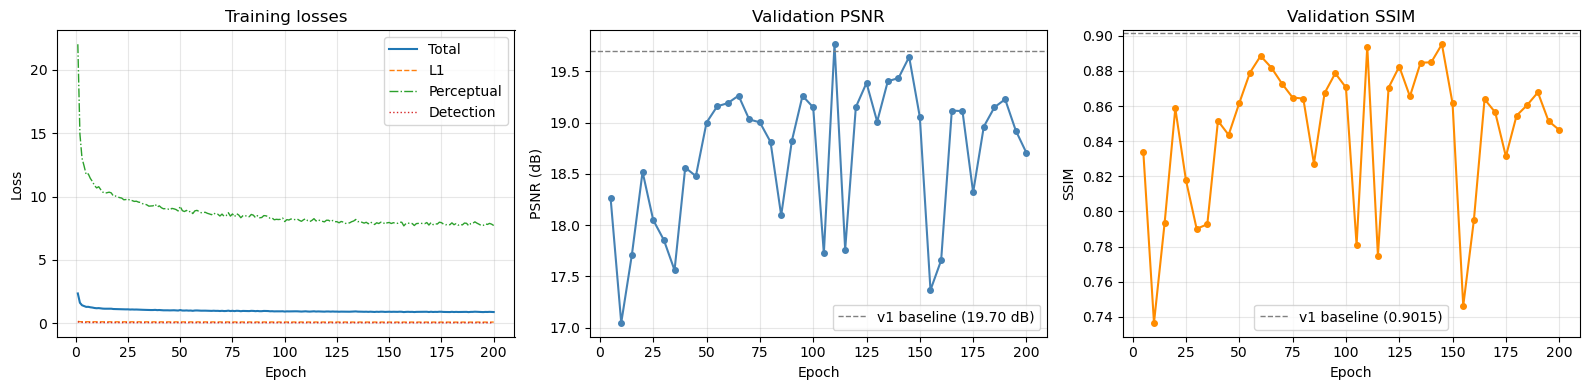

Best PSNR: 19.77 dB  |  Best SSIM: 0.8952


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

epochs_all = range(1, len(history['loss']) + 1)

# Loss components
ax = axes[0]
ax.plot(epochs_all, history['loss'],  label='Total',      linewidth=1.5)
ax.plot(epochs_all, history['l1'],    label='L1',         linewidth=1,   linestyle='--')
ax.plot(epochs_all, history['perc'],  label='Perceptual', linewidth=1,   linestyle='-.')
ax.plot(epochs_all, history['det'],   label='Detection',  linewidth=1,   linestyle=':')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.set_title('Training losses')
ax.legend(); ax.grid(alpha=0.3)

# PSNR
ax = axes[1]
ax.plot(history['val_epochs'], history['psnr'], 'o-', color='steelblue', linewidth=1.5, markersize=4)
ax.axhline(19.70, color='gray', linestyle='--', linewidth=1, label='v1 baseline (19.70 dB)')
ax.set_xlabel('Epoch'); ax.set_ylabel('PSNR (dB)'); ax.set_title('Validation PSNR')
ax.legend(); ax.grid(alpha=0.3)

# SSIM
ax = axes[2]
ax.plot(history['val_epochs'], history['ssim'], 'o-', color='darkorange', linewidth=1.5, markersize=4)
ax.axhline(0.9015, color='gray', linestyle='--', linewidth=1, label='v1 baseline (0.9015)')
ax.set_xlabel('Epoch'); ax.set_ylabel('SSIM'); ax.set_title('Validation SSIM')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Best PSNR: {max(history['psnr']):.2f} dB  |  Best SSIM: {max(history['ssim']):.4f}")

---
## 8 — Load Best Checkpoint & Visualise Results

In [9]:
# ── Load best checkpoint ──────────────────────────────────────────────────────
ckpt = torch.load(Path(CFG['ckpt_dir']) / 'best.pt', map_location=DEVICE)
llen.load_state_dict(ckpt['llen_state'])
dgff.load_state_dict(ckpt['dgff_state'])
print(f"Loaded checkpoint from epoch {ckpt['epoch']}  "
      f"PSNR={ckpt['val_psnr']:.2f}dB  SSIM={ckpt['val_ssim']:.4f}")

# ── Full val set PSNR/SSIM with best model ────────────────────────────────────
val_psnr, val_ssim = validate(llen, dgff, val_loader, DEVICE)
print(f"Final val  PSNR: {val_psnr:.2f} dB   SSIM: {val_ssim:.4f}")

Loaded checkpoint from epoch 110  PSNR=19.77dB  SSIM=0.8939
Final val  PSNR: 19.77 dB   SSIM: 0.8939


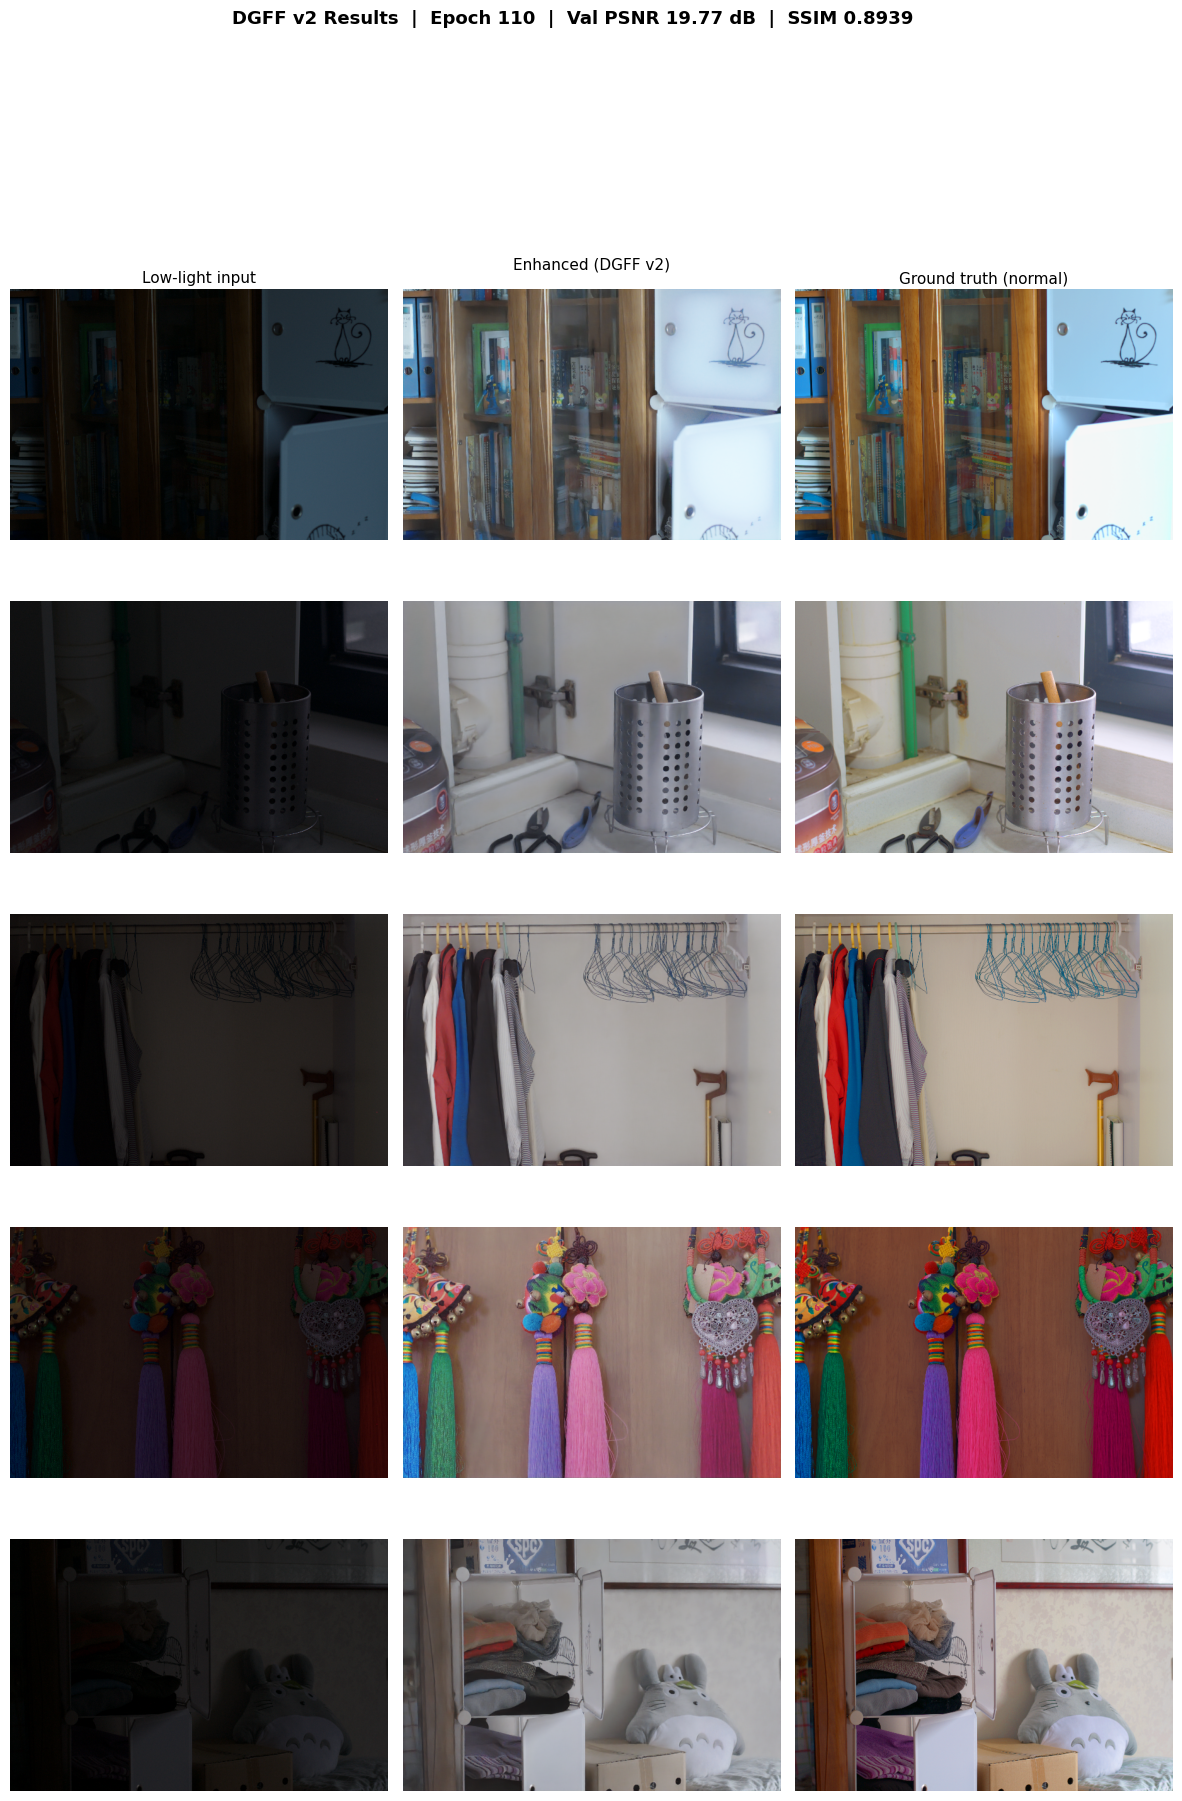

Saved → dgff_v2_results.png


In [10]:
# ── Visual comparison: low / enhanced / ground-truth ─────────────────────────
llen.eval(); dgff.eval()

N_SHOW = 5   # number of validation images to display

fig = plt.figure(figsize=(15, 4 * N_SHOW))
gs  = gridspec.GridSpec(N_SHOW, 3, hspace=0.08, wspace=0.04)

col_titles = ['Low-light input', 'Enhanced (DGFF v2)', 'Ground truth (normal)']

to_np = lambda t: t.squeeze(0).permute(1, 2, 0).cpu().numpy().clip(0, 1)

with torch.no_grad():
    for row, (low, high, fname) in enumerate(val_loader):
        if row >= N_SHOW: break
        low, high        = low.to(DEVICE), high.to(DEVICE)
        enhanced         = llen(low)
        p4, p5           = dgff(enhanced)
        enhanced_guided  = llen(low, dgff_p5=p5, dgff_p4=p4)

        img_psnr = compute_psnr(enhanced_guided, high)
        img_ssim = compute_ssim(enhanced_guided, high)

        for col, (img, title) in enumerate(zip(
            [low, enhanced_guided, high], col_titles
        )):
            ax = fig.add_subplot(gs[row, col])
            ax.imshow(to_np(img))
            ax.axis('off')
            if row == 0:
                ax.set_title(title, fontsize=11, pad=4)
            if col == 1:
                ax.set_xlabel(f'PSNR {img_psnr:.2f} dB  |  SSIM {img_ssim:.4f}',
                              fontsize=8)
                ax.xaxis.set_label_position('top')

fig.suptitle(
    f"DGFF v2 Results  |  Epoch {ckpt['epoch']}  |  "
    f"Val PSNR {val_psnr:.2f} dB  |  SSIM {val_ssim:.4f}",
    fontsize=13, fontweight='bold', y=1.01
)
plt.savefig('dgff_v2_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → dgff_v2_results.png")

---
## 9 — Ablation: λ_det Sensitivity

In [11]:
"""
Quick ablation: train for a smaller number of epochs (e.g. 50) with
different lambda_det values to find the sweet spot.

Swap CFG['lambda_det'] and CFG['epochs'] below and re-run Section 5+6
for each row.  Collect val PSNR and (when ExDark is available) mAP.

| lambda_det | PSNR (LOL) | mAP (ExDark) |
|------------|------------|---------------|
| 0.0        | ?          | ?  (no det loss — baseline)
| 0.1        | ?          | ?
| 0.5        | ?          | ?  (default)
| 1.0        | ?          | ?

Expected: PSNR may dip slightly as lambda_det increases,
          mAP should peak around 0.5–1.0.
"""

# To run a quick ablation change these values and re-execute cells 5 & 6:
# CFG['lambda_det'] = 0.0   # no detection loss — equivalent to v1
# CFG['epochs']     = 50    # short run for ablation

print("Ablation cell — edit CFG values and re-run cells 5 & 6.")
print(f"Current lambda_det = {CFG['lambda_det']}")

Ablation cell — edit CFG values and re-run cells 5 & 6.
Current lambda_det = 0.5


---
## 10 — Inference Only (load checkpoint, enhance a single image)

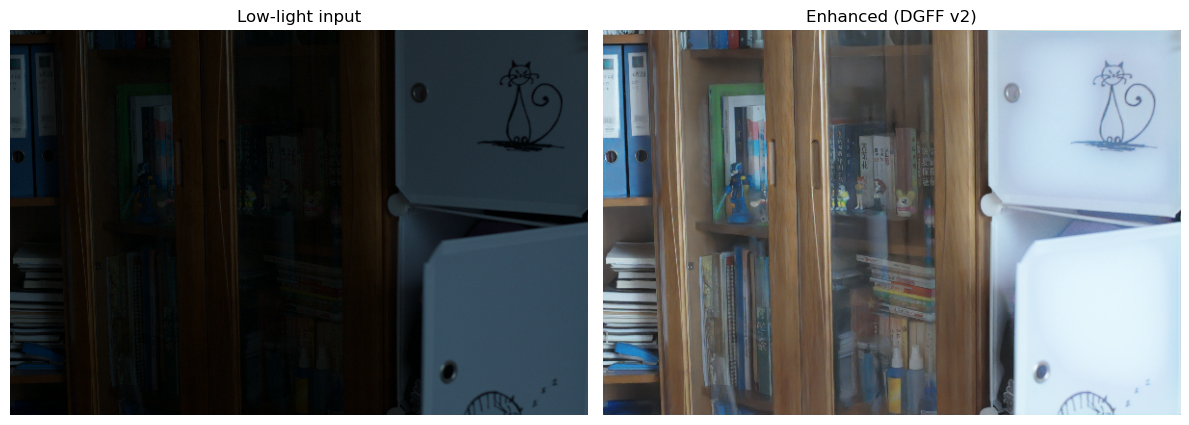

In [12]:
def enhance_single(image_path, llen, dgff, device):
    """
    Enhance one low-light image using the trained LLEN + DGFF pipeline.
    At inference DGFF features are extracted once and used for guided enhancement.
    DGFF is discarded after this call — zero overhead vs standalone LLEN.

    Args:
        image_path : str or Path to the low-light image
        llen       : trained LLEN model
        dgff       : trained DGFFModule
        device     : torch device

    Returns:
        enhanced_np : (H, W, 3) numpy array in [0, 1]
    """
    llen.eval(); dgff.eval()

    img    = Image.open(image_path).convert('RGB')
    tensor = T.ToTensor()(img).unsqueeze(0).to(device)  # (1, 3, H, W)

    with torch.no_grad():
        enhanced        = llen(tensor)
        p4, p5          = dgff(enhanced)
        enhanced_guided = llen(tensor, dgff_p5=p5, dgff_p4=p4)

    return enhanced_guided.squeeze(0).permute(1, 2, 0).cpu().numpy().clip(0, 1)


# ── Example: enhance the first val image ─────────────────────────────────────
val_set    = val_loader.dataset
sample_low = str(val_set.low_dir / val_set.filenames[0])
result     = enhance_single(sample_low, llen, dgff, DEVICE)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.imshow(np.array(Image.open(sample_low).convert('RGB')))
ax1.set_title('Low-light input'); ax1.axis('off')
ax2.imshow(result)
ax2.set_title('Enhanced (DGFF v2)'); ax2.axis('off')
plt.tight_layout()
plt.show()

---
## 11 — ExDark: Dataset & YOLO-format Converter

ExDark structure after download:
```
ExDark/
├── images/
│   ├── Bicycle/  Boat/  Bottle/  Bus/  Car/  Cat/
│   ├── Chair/    Cup/   Dog/     Motorbike/ People/ Table/
├── Annotations/   (same 12 subfolders, .txt per image)
└── imageclasslist.txt   (train / val / test split labels)
```

This cell converts ExDark annotations → YOLO format, splits into
train/val/test, and writes a `data.yaml` ready for `yolo val`.
Run once. Safe to re-run (skips already-converted files).

In [11]:
# ── ExDark paths (add to CFG) ─────────────────────────────────────────────────
CFG['exdark_root'] = './ExDark'       # your downloaded ExDark folder
CFG['exdark_yolo'] = './yolo_format'  # output — created automatically

EXDARK_CLASSES = [
    'Bicycle', 'Boat', 'Bottle', 'Bus', 'Car', 'Cat',
    'Chair', 'Cup', 'Dog', 'Motorbike', 'People', 'Table'
]
CLASS_TO_ID = {c: i for i, c in enumerate(EXDARK_CLASSES)}

print("ExDark class → ID:")
for cls, idx in CLASS_TO_ID.items():
    print(f"  {idx:2d}  {cls}")


ExDark class → ID:
   0  Bicycle
   1  Boat
   2  Bottle
   3  Bus
   4  Car
   5  Cat
   6  Chair
   7  Cup
   8  Dog
   9  Motorbike
  10  People
  11  Table


In [23]:
import os

for root, dirs, files in os.walk(CFG['exdark_root']):
    level = root.replace(CFG['exdark_root'], '').count(os.sep)
    if level > 2:
        continue
    indent = ' ' * level
    print(f'{indent}{os.path.basename(root)}/')
    if level == 2:
        print(f'{indent} ({len(files)} files)')

ExDark/
 Cat/
 Car/
 Cup/
 Dog/
 Groundtruth/
 Dataset/
 Boat/
 Chair/
 Bus/
 Motorbike/
 Table/
 People/
 .ipynb_checkpoints/
 Bicycle/
 Bottle/
 SPIC/


In [3]:
from pathlib import Path
exdark_root = Path(CFG['exdark_root'])
print(list(exdark_root.glob('*')))                # top-level content
print(list((exdark_root / 'Groundtruth').glob('*')))  # what's inside Groundtruth?

[PosixPath('ExDark/Cat'), PosixPath('ExDark/Car'), PosixPath('ExDark/Cup'), PosixPath('ExDark/.DS_Store'), PosixPath('ExDark/LICENSE'), PosixPath('ExDark/Dog'), PosixPath('ExDark/Groundtruth'), PosixPath('ExDark/Dataset'), PosixPath('ExDark/Boat'), PosixPath('ExDark/Chair'), PosixPath('ExDark/Bus'), PosixPath('ExDark/Motorbike'), PosixPath('ExDark/README.md'), PosixPath('ExDark/Table'), PosixPath('ExDark/People'), PosixPath('ExDark/.ipynb_checkpoints'), PosixPath('ExDark/Bicycle'), PosixPath('ExDark/Bottle'), PosixPath('ExDark/Exdark.gif'), PosixPath('ExDark/SPIC')]
[PosixPath('ExDark/Groundtruth/annotations.png'), PosixPath('ExDark/Groundtruth/exdark1.png'), PosixPath('ExDark/Groundtruth/README.md'), PosixPath('ExDark/Groundtruth/imageclasslist.txt')]


In [4]:
from pathlib import Path

# If you have CFG dict, use that; otherwise set path explicitly
exdark_root = Path('/Users/shuvrosankar/miniconda3/MSCS/CVPR/Project')  # adjust as needed
gt = exdark_root / 'Groundtruth'

print(f"Checking path: {gt.absolute()}")
print(f"Does path exist? {gt.exists()}")
print(f"Is it a directory? {gt.is_dir()}")

if gt.exists() and gt.is_dir():
    # List all contents (files and folders)
    all_items = list(gt.iterdir())
    print(f"Total items in Groundtruth: {len(all_items)}")
    print("First 10 items:", [item.name for item in all_items[:10]])
    
    # Specifically look for directories
    subdirs = [d.name for d in gt.iterdir() if d.is_dir()]
    print(f"Subdirectories found: {subdirs}")
else:
    print("Groundtruth not found at that location")

Checking path: /Users/shuvrosankar/miniconda3/MSCS/CVPR/Project/Groundtruth
Does path exist? True
Is it a directory? True
Total items in Groundtruth: 18
First 10 items: ['Cat', 'annotations.png', 'Car', 'Cup', '.DS_Store', 'Dog', 'Boat', 'Chair', 'Bus', 'exdark1.png']
Subdirectories found: ['Cat', 'Car', 'Cup', 'Dog', 'Boat', 'Chair', 'Bus', 'Motorbike', 'Table', 'People', '.ipynb_checkpoints', 'Bicycle', 'Bottle']


In [5]:
from pathlib import Path
p = Path('/Users/shuvrosankar/miniconda3/MSCS/CVPR/Project')
print([d.name for d in p.iterdir() if d.is_dir()])

['yolo_format', 'LOL', 'Groundtruth', 'Dataset', 'claude', 'checkpoints', '__pycache__', 'ExDark', '.ipynb_checkpoints', 'SPIC']


In [6]:
from pathlib import Path

project = Path('/Users/shuvrosankar/miniconda3/MSCS/CVPR/Project')
print("Contents of project directory:")
for item in project.iterdir():
    if item.is_dir():
        print(f"  📁 {item.name}")
    else:
        print(f"  📄 {item.name}")

# Also check inside ExDark folder (if it still exists)
exdark_folder = project / 'ExDark'
if exdark_folder.exists():
    print("\nContents of ExDark/ (still exists?):")
    for item in exdark_folder.iterdir():
        if item.is_dir():
            print(f"  📁 {item.name}")

Contents of project directory:
  📁 yolo_format
  📄 .DS_Store
  📁 LOL
  📄 LICENSE
  📄 DGFF_full.ipynb
  📄 yolov8n.pt
  📁 Groundtruth
  📁 Dataset
  📄 dgff_v2_results.png
  📁 claude
  📁 checkpoints
  📄 llen.py
  📄 dgff.py
  📄 LOL_load.ipynb
  📄 dgff_v2.py
  📁 __pycache__
  📄 training_curves.png
  📄 README.md
  📄 train.py
  📁 ExDark
  📁 .ipynb_checkpoints
  📄 train_v2.py
  📄 lol_dataset.py
  📄 train.ipynb
  📄 DGFF_full-Copy1.ipynb
  📄 Exdark.gif
  📄 dgff_results.png
  📁 SPIC
  📄 lol_sample.png
  📄 DGFF_full_exdark.ipynb

Contents of ExDark/ (still exists?):
  📁 Cat
  📁 Car
  📁 Cup
  📁 Dog
  📁 Groundtruth
  📁 Dataset
  📁 Boat
  📁 Chair
  📁 Bus
  📁 Motorbike
  📁 Table
  📁 People
  📁 .ipynb_checkpoints
  📁 Bicycle
  📁 Bottle
  📁 SPIC


Split map: 7364 entries  (3001 train / 1800 val / 2563 test)
  [WARN] Groundtruth/Bicycle/ not found — skipping
  [WARN] Groundtruth/Boat/ not found — skipping
  [WARN] Groundtruth/Bottle/ not found — skipping
  [WARN] Groundtruth/Bus/ not found — skipping
  [WARN] Groundtruth/Car/ not found — skipping
  [WARN] Groundtruth/Cat/ not found — skipping
  [WARN] Groundtruth/Chair/ not found — skipping
  [WARN] Groundtruth/Cup/ not found — skipping
  [WARN] Groundtruth/Dog/ not found — skipping
  [WARN] Groundtruth/Motorbike/ not found — skipping
  [WARN] Groundtruth/People/ not found — skipping
  [WARN] Groundtruth/Table/ not found — skipping

Conversion complete:
  0 converted, 0 already existed, 0 errors


In [51]:
from pathlib import Path
p = Path('/Users/shuvrosankar/miniconda3/MSCS/CVPR/Project')
print((p / 'ExDark' / 'Car').exists())          # Should be True
print((p / 'Groundtruth' / 'Car').exists())     # Should be True (you saw earlier it exists)
print((p / 'Groundtruth' / 'imageclasslist.txt').exists())  # True

True
True
True


In [52]:
import shutil
from pathlib import Path
from PIL import Image

# ExDark classes in order (0-indexed)
EXDARK_CLASSES = [
    'Bicycle', 'Boat', 'Bottle', 'Bus', 'Car', 'Cat',
    'Chair', 'Cup', 'Dog', 'Motorbike', 'People', 'Table'
]
CLASS_TO_ID = {name: idx for idx, name in enumerate(EXDARK_CLASSES)}

def convert_exdark_to_yolo(project_root, yolo_root):
    """
    Convert ExDark to YOLO format.
    
    Assumed structure:
        project_root/
        ├── ExDark/            (images)
        │   ├── Car/
        │   ├── Boat/
        │   └── ...
        └── Groundtruth/       (annotations)
            ├── Car/
            ├── Boat/
            ├── imageclasslist.txt
            └── ...
    """
    project_root = Path(project_root)
    yolo_root = Path(yolo_root)
    
    img_base = project_root / 'ExDark'
    ann_base = project_root / 'Groundtruth'
    classlist = ann_base / 'imageclasslist.txt'
    
    if not classlist.exists():
        print(f'[ERROR] {classlist} not found')
        return 0
    
    # Read split map
    split_map = {}
    with open(classlist) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5:
                split_map[parts[0]] = {'1':'train','2':'val','3':'test'}.get(parts[4], 'train')
    
    print(f'Split map: {len(split_map)} entries  '
          f'(train: {sum(v=="train" for v in split_map.values())}, '
          f'val: {sum(v=="val" for v in split_map.values())}, '
          f'test: {sum(v=="test" for v in split_map.values())})')
    
    converted = skipped = errors = 0
    
    for cls_name in EXDARK_CLASSES:
        img_dir = img_base / cls_name
        ann_dir = ann_base / cls_name
        
        if not img_dir.exists():
            print(f'  [WARN] Images missing: {img_dir}')
            continue
        if not ann_dir.exists():
            print(f'  [WARN] Annotations missing: {ann_dir}')
            continue
        
        ann_files = sorted(ann_dir.glob('*.txt'))
        cls_id = CLASS_TO_ID[cls_name]
        print(f'  {cls_name:<12}: {len(ann_files)} annotation files')
        
        for ann_file in ann_files:
            stem = ann_file.stem
            
            # Find matching image (any common extension)
            candidates = [p for p in img_dir.glob(f'{stem}.*')
                          if p.suffix.lower() in ('.jpg','.jpeg','.png','.bmp')]
            if not candidates:
                errors += 1
                continue
            img_path = candidates[0]
            
            split = split_map.get(img_path.name, 'train')
            out_img_dir = yolo_root / 'images' / split
            out_lbl_dir = yolo_root / 'labels' / split
            out_img_dir.mkdir(parents=True, exist_ok=True)
            out_lbl_dir.mkdir(parents=True, exist_ok=True)
            
            out_lbl = out_lbl_dir / f'{stem}.txt'
            out_img = out_img_dir / img_path.name
            
            if out_lbl.exists():
                skipped += 1
                continue
            
            # Get image dimensions
            try:
                with Image.open(img_path) as im:
                    W, H = im.size
            except Exception:
                errors += 1
                continue
            
            # Parse annotation file
            yolo_lines = []
            for line in ann_file.read_text().splitlines():
                line = line.strip()
                if not line or line.startswith('%'):
                    continue
                parts = line.split()
                if len(parts) < 5:
                    continue
                try:
                    # Format: <class> left top width height ...
                    l, t, w, h = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
                    cx = (l + w/2) / W
                    cy = (t + h/2) / H
                    wn = w / W
                    hn = h / H
                    # Clamp to [0,1]
                    cx = max(0.0, min(1.0, cx))
                    cy = max(0.0, min(1.0, cy))
                    wn = max(0.0, min(1.0, wn))
                    hn = max(0.0, min(1.0, hn))
                    if wn > 0 and hn > 0:
                        yolo_lines.append(f'{cls_id} {cx:.6f} {cy:.6f} {wn:.6f} {hn:.6f}')
                except (ValueError, IndexError):
                    continue
            
            if yolo_lines:
                out_lbl.write_text('\n'.join(yolo_lines))
                shutil.copy2(img_path, out_img)
                converted += 1
            else:
                errors += 1
    
    print(f'\nConversion complete:')
    print(f'  Converted: {converted}, Skipped (exists): {skipped}, Errors: {errors}')
    return converted

# ========== RUN ==========
project_root = '/Users/shuvrosankar/miniconda3/MSCS/CVPR/Project'
yolo_output  = '/Users/shuvrosankar/miniconda3/MSCS/CVPR/Project/yolo_format'

converted = convert_exdark_to_yolo(project_root, yolo_output)

Split map: 7364 entries  (train: 3001, val: 1800, test: 2563)
  Bicycle     : 652 annotation files
  Boat        : 679 annotation files
  Bottle      : 547 annotation files
  Bus         : 527 annotation files
  Car         : 638 annotation files
  Cat         : 735 annotation files
  Chair       : 648 annotation files
  Cup         : 519 annotation files
  Dog         : 801 annotation files
  Motorbike   : 503 annotation files
  People      : 609 annotation files
  Table       : 505 annotation files

Conversion complete:
  Converted: 0, Skipped (exists): 0, Errors: 7363


In [53]:
from pathlib import Path
p = Path('/Users/shuvrosankar/miniconda3/MSCS/CVPR/Project')
ann_example = p / 'Groundtruth' / 'Car' / (list((p/'Groundtruth'/'Car').glob('*.txt'))[0].name)
print(ann_example.read_text()[:500])

% bbGt version=3
Car 514 284 283 123 0 0 0 0 0 0 0



In [54]:
stem = ann_example.stem
img_dir = p / 'ExDark' / 'Car'
print(list(img_dir.glob(f'{stem}.*')))

[]


In [55]:
with open(p/'Groundtruth'/'imageclasslist.txt') as f:
    for i, line in enumerate(f):
        if i<5:
            print(line.strip())

Name | Class | Light | In/Out | Train/Val/Test
2015_00001.png 1 2 1 1
2015_00002.png 1 6 2 1
2015_00003.png 1 5 2 1
2015_00004.jpg 1 3 2 1


In [56]:
from pathlib import Path

p = Path('/Users/shuvrosankar/miniconda3/MSCS/CVPR/Project')
ann_car = p / 'Groundtruth' / 'Car'
img_car = p / 'ExDark' / 'Car'

# List first 5 annotation files
ann_files = sorted(ann_car.glob('*.txt'))[:5]
print("Annotation files:", [f.name for f in ann_files])

# List first 5 image files
img_files = sorted(img_car.glob('*.*'))[:5]
print("Image files:", [f.name for f in img_files])

# For the first annotation, check if any image matches its stem
if ann_files:
    stem = ann_files[0].stem
    matches = list(img_car.glob(f'{stem}.*'))
    print(f"\nStem of first annotation: {stem}")
    print(f"Matching images: {[m.name for m in matches]}")

Annotation files: ['2015_02406.jpg.txt', '2015_02407.jpg.txt', '2015_02408.jpg.txt', '2015_02409.jpg.txt', '2015_02410.png.txt']
Image files: ['2015_02406.jpg', '2015_02407.jpg', '2015_02408.jpg', '2015_02409.jpg', '2015_02410.png']

Stem of first annotation: 2015_02406.jpg
Matching images: []


In [57]:
ann_file = ann_files[0]
content = ann_file.read_text().splitlines()
print("Full content of one annotation file:")
for i, line in enumerate(content[:10]):
    print(f"{i}: {line}")

Full content of one annotation file:
0: % bbGt version=3
1: Car 47 135 299 134 0 0 0 0 0 0 0


In [58]:
print("Subdirectories in ExDark/Car:", [d.name for d in img_car.iterdir() if d.is_dir()])

Subdirectories in ExDark/Car: []


In [60]:
import shutil
from pathlib import Path
from PIL import Image

EXDARK_CLASSES = ['Bicycle','Boat','Bottle','Bus','Car','Cat','Chair','Cup','Dog','Motorbike','People','Table']
CLASS_TO_ID = {name: idx for idx, name in enumerate(EXDARK_CLASSES)}

def convert_exdark_to_yolo(project_root, yolo_root):
    project_root = Path(project_root)
    yolo_root = Path(yolo_root)
    ann_base = project_root / 'Groundtruth'
    img_base = project_root / 'ExDark'
    classlist = ann_base / 'imageclasslist.txt'
    
    if not classlist.exists():
        print(f'ERROR: {classlist} not found')
        return 0
    
    # Read split map
    split_map = {}
    with open(classlist) as f:
        first_line = f.readline().strip()
        # Check if first line is a header (contains '|' or 'Name')
        if '|' in first_line or first_line.lower().startswith('name'):
            pass  # skip header
        else:
            # Process first line as data
            parts = first_line.split()
            if len(parts) >= 5:
                split_map[parts[0]] = {'1':'train','2':'val','3':'test'}.get(parts[4], 'train')
        
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            if len(parts) >= 5:
                img_name = parts[0]
                split = {'1':'train','2':'val','3':'test'}.get(parts[4], 'train')
                split_map[img_name] = split
    
    print(f'Found {len(split_map)} images in split file')
    
    converted = skipped = errors = 0
    
    for img_name, split in split_map.items():
        # Determine class by looking for annotation file in Groundtruth subdirs
        found_class = None
        ann_path = None
        for cls_name in EXDARK_CLASSES:
            # Annotation file is named <image_name>.txt (e.g., '2015_02406.jpg.txt')
            candidate_ann = ann_base / cls_name / f'{img_name}.txt'
            if candidate_ann.exists():
                found_class = cls_name
                ann_path = candidate_ann
                break
        if found_class is None:
            errors += 1
            continue
        
        # Find image file
        img_dir = img_base / found_class
        img_path = img_dir / img_name
        if not img_path.exists():
            # Fallback: try different extension (just in case)
            stem = Path(img_name).stem
            candidates = list(img_dir.glob(f'{stem}.*'))
            if not candidates:
                errors += 1
                continue
            img_path = candidates[0]
        
        # Output paths
        out_img_dir = yolo_root / 'images' / split
        out_lbl_dir = yolo_root / 'labels' / split
        out_img_dir.mkdir(parents=True, exist_ok=True)
        out_lbl_dir.mkdir(parents=True, exist_ok=True)
        
        out_lbl = out_lbl_dir / f'{Path(img_name).stem}.txt'
        out_img = out_img_dir / img_path.name
        
        if out_lbl.exists():
            skipped += 1
            continue
        
        # Get image size
        try:
            with Image.open(img_path) as im:
                W, H = im.size
        except Exception:
            errors += 1
            continue
        
        # Parse annotation file
        cls_id = CLASS_TO_ID[found_class]
        yolo_lines = []
        for line in ann_path.read_text().splitlines():
            line = line.strip()
            if not line or line.startswith('%'):
                continue
            parts = line.split()
            if len(parts) < 5:
                continue
            try:
                # Format: <class> left top width height ...
                l, t, w, h = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
                cx = (l + w/2) / W
                cy = (t + h/2) / H
                wn = w / W
                hn = h / H
                cx = max(0.0, min(1.0, cx))
                cy = max(0.0, min(1.0, cy))
                wn = max(0.0, min(1.0, wn))
                hn = max(0.0, min(1.0, hn))
                if wn > 0 and hn > 0:
                    yolo_lines.append(f'{cls_id} {cx:.6f} {cy:.6f} {wn:.6f} {hn:.6f}')
            except (ValueError, IndexError):
                continue
        
        if yolo_lines:
            out_lbl.write_text('\n'.join(yolo_lines))
            shutil.copy2(img_path, out_img)
            converted += 1
        else:
            errors += 1
        
        if converted % 500 == 0:
            print(f'Processed {converted} images...')
    
    print(f'\nConversion complete: {converted} converted, {skipped} skipped, {errors} errors')
    return converted

# Run
project_root = '/Users/shuvrosankar/miniconda3/MSCS/CVPR/Project'
yolo_output = '/Users/shuvrosankar/miniconda3/MSCS/CVPR/Project/yolo_format'
convert_exdark_to_yolo(project_root, yolo_output)

Found 7363 images in split file
Processed 500 images...
Processed 1000 images...
Processed 1500 images...
Processed 2000 images...
Processed 2500 images...
Processed 3000 images...
Processed 3500 images...
Processed 4000 images...
Processed 4500 images...
Processed 5000 images...
Processed 5500 images...
Processed 6000 images...
Processed 6500 images...
Processed 7000 images...

Conversion complete: 7362 converted, 0 skipped, 1 errors


7362

In [8]:
from pathlib import Path
import yaml

# Use the actual absolute path where the dataset was saved
yolo_root = Path('/Users/shuvrosankar/miniconda3/MSCS/CVPR/Project/yolo_format')

data_yaml = {
    'path': str(yolo_root),
    'train': 'images/train',
    'val': 'images/val',
    'test': 'images/test',
    'nc': 12,
    'names': ['Bicycle','Boat','Bottle','Bus','Car','Cat','Chair','Cup','Dog','Motorbike','People','Table']
}

yaml_path = yolo_root / 'data.yaml'
yaml_path.parent.mkdir(parents=True, exist_ok=True)   # ensure directory exists

with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False, sort_keys=False)

print(f'Written: {yaml_path}')
print()
for split in ('train', 'val', 'test'):
    img_dir = yolo_root / 'images' / split
    if img_dir.exists():
        imgs = list(img_dir.glob('*.*'))
        imgs = [p for p in imgs if p.suffix.lower() in ('.jpg','.jpeg','.png','.bmp')]
        print(f'  {split:5s}: {len(imgs):5d} images')
    else:
        print(f'  {split:5s}: directory not found')

Written: /Users/shuvrosankar/miniconda3/MSCS/CVPR/Project/yolo_format/data.yaml

  train:  2999 images
  val  :  1800 images
  test :  2563 images


---
## 12 — ExDark Dataloader (enhance-then-detect pipeline)

This loader wraps ExDark images for two purposes:
- **mAP evaluation**: load raw low-light images → enhance with LLEN → detect with YOLOv8
- **Fine-tuning** (optional, Section 14): continue training LLEN on ExDark using only `L_det`
  (no paired references, so pixel/perceptual loss is skipped)

In [12]:
class ExDarkDataset(Dataset):
    """
    Loads ExDark images from the YOLO-converted folder.
    Returns: (image_tensor, label_path, image_path)

    image_tensor : (3, H, W) float32 in [0, 1]  — the raw low-light image
    label_path   : str path to the YOLO .txt annotation file
    image_path   : str — original path (for saving enhanced images / debugging)

    No augmentation is applied here — this loader is used for evaluation
    and for fine-tuning with the detection feature loss only.
    """
    def __init__(self, yolo_root, split='test', img_size=640):
        self.img_size  = img_size
        root           = Path(yolo_root) / 'images' / split
        self.img_paths = sorted([
            p for p in root.rglob('*')
            if p.suffix.lower() in ('.jpg', '.jpeg', '.png', '.bmp')
        ])
        if not self.img_paths:
            raise FileNotFoundError(f"No images found under {root}")

        self.to_tensor = T.ToTensor()
        print(f"ExDarkDataset [{split}]: {len(self.img_paths)} images")

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        img      = Image.open(img_path).convert('RGB')

        # Resize to a fixed size for consistent batching
        # (ExDark images vary in resolution)
        img = img.resize((self.img_size, self.img_size), Image.BILINEAR)

        tensor    = self.to_tensor(img)                          # (3, H, W) in [0,1]
        lbl_path  = str(img_path).replace('/images/', '/labels/').rsplit('.', 1)[0] + '.txt'
        return tensor, lbl_path, str(img_path)


# Quick check — comment out if ExDark isn't downloaded yet
try:
    exdark_test_set = ExDarkDataset(CFG['exdark_yolo'], split='test', img_size=640)
    exdark_val_set  = ExDarkDataset(CFG['exdark_yolo'], split='val',  img_size=640)
    exdark_test_loader = DataLoader(exdark_test_set, batch_size=4,
                                    shuffle=False, num_workers=CFG['num_workers'])
    exdark_val_loader  = DataLoader(exdark_val_set,  batch_size=4,
                                    shuffle=False, num_workers=CFG['num_workers'])
    print("ExDark loaders ready ✓")
except FileNotFoundError as e:
    print(f"[INFO] ExDark not found yet: {e}")
    print("  Run Section 11 first to convert the dataset.")


ExDarkDataset [test]: 2563 images
ExDarkDataset [val]: 1800 images
ExDark loaders ready ✓


---
## 13 — Load LOL-Trained Checkpoint & Freeze LLEN

The LOL-trained `best.pt` contains both `llen_state` and `dgff_state`.

**What we freeze:** the entire LLEN — all encoder, decoder, and head weights.  
**What stays trainable:** only the two DGFF gated adapters (`adapter_p4`, `adapter_p5`).

This is correct because:
- LLEN has learned general low-light → normal-light mapping from LOL
- On ExDark we have no paired references, so we cannot supervise pixel reconstruction
- The adapters can be fine-tuned with `L_det` alone to adapt the feature feedback
  to the new domain (indoor clutter → street/outdoor objects)

In [17]:
# ── Rebuild models (safe to re-run) ──────────────────────────────────────────
llen = LLEN(base_ch=CFG['base_ch']).to(DEVICE)
dgff = DGFFModule(
    yolo_weights    = CFG['yolo_weights'],
    llen_base_ch    = CFG['base_ch'],
    freeze_backbone = True,
).to(DEVICE)

# ── Load LOL checkpoint ───────────────────────────────────────────────────────
ckpt_path = Path(CFG['ckpt_dir']) / 'best.pt'
ckpt      = torch.load(ckpt_path, map_location=DEVICE)
llen.load_state_dict(ckpt['llen_state'])
dgff.load_state_dict(ckpt['dgff_state'])
print(f"Loaded checkpoint: epoch {ckpt['epoch']}  "
      f"LOL PSNR={ckpt['val_psnr']:.2f}dB  SSIM={ckpt['val_ssim']:.4f}")

# ── Freeze LLEN entirely ──────────────────────────────────────────────────────
for p in llen.parameters():
    p.requires_grad_(False)
llen.eval()

frozen_count = sum(1 for p in llen.parameters() if not p.requires_grad)
print(f"LLEN frozen: {frozen_count} parameter tensors locked")

# ── Confirm what is still trainable ──────────────────────────────────────────
trainable_exdark = (
    list(dgff.adapter_p4.parameters()) +
    list(dgff.adapter_p5.parameters())
)
n_trainable = sum(p.numel() for p in trainable_exdark)
print(f"Trainable on ExDark: DGFF adapters only — {n_trainable:,} parameters")


Loaded checkpoint: epoch 110  LOL PSNR=19.77dB  SSIM=0.8939
LLEN frozen: 87 parameter tensors locked
Trainable on ExDark: DGFF adapters only — 82,304 parameters


---
## 14 — ExDark Fine-Tuning (adapter-only, detection loss only)

No paired references on ExDark, so we drop L1 and perceptual losses entirely.
Only `L_det` (backbone feature alignment against the enhanced image itself,
since we want consistent features — not matched to a clean reference).

**Loss on ExDark:**  
`L_det = MSE( backbone(enhanced_guided), backbone(enhanced_guided).detach() )`  
→ This is a **self-consistency** loss: the guided enhancement should produce
stable, repeatable backbone features across the two passes.

Alternatively you can skip fine-tuning entirely and go straight to Section 15
(mAP evaluation) — the LOL-trained model already generalises reasonably well.

In [19]:
# ── Self-consistency detection loss for unpaired data ─────────────────────────
class SelfConsistencyDetLoss(nn.Module):
    """
    On datasets with no paired clean reference (ExDark, DarkFace),
    we cannot compute MSE(enhanced, clean_backbone).

    Instead we enforce that Pass-1 and Pass-2 (guided) enhanced images
    produce similar backbone features — the DGFF feedback should refine
    features, not radically change them. This keeps the adapters from
    drifting during fine-tuning.
    """
    def __init__(self, dgff_module):
        super().__init__()
        self.backbone = dgff_module.backbone

    def _feats(self, x):
        feats = []
        for i, layer in enumerate(self.backbone):
            x = layer(x)
            if i in (6, 9):
                feats.append(x)
        return feats

    def forward(self, enhanced_pass1, enhanced_guided):
        with torch.no_grad():
            f1 = self._feats(enhanced_pass1)   # stable target — no grad
        f2 = self._feats(enhanced_guided)       # guided output — grad flows
        return sum(F.mse_loss(a, b.detach()) for a, b in zip(f2, f1))


# ── Fine-tune setup ───────────────────────────────────────────────────────────
self_det_loss  = SelfConsistencyDetLoss(dgff).to(DEVICE)

ft_optimiser   = Adam(trainable_exdark, lr=1e-5, betas=(0.9, 0.999))  # low LR
ft_scheduler   = CosineAnnealingLR(ft_optimiser, T_max=20, eta_min=1e-7)

FT_EPOCHS      = 20   # short fine-tune — adapters only, dataset is unlabelled

print(f"Fine-tuning for {FT_EPOCHS} epochs on ExDark (adapters only)")
print(f"Trainable params: {sum(p.numel() for p in trainable_exdark):,}")


Fine-tuning for 20 epochs on ExDark (adapters only)
Trainable params: 82,304


In [22]:
ft_history = dict(loss=[])

for epoch in range(1, FT_EPOCHS + 1):
    dgff.train()
    llen.eval()   # LLEN stays frozen throughout

    ep_loss = 0.0
    t0      = time.perf_counter()

    for imgs, _, _ in exdark_val_loader:   # use val split for fine-tuning
        imgs = imgs.to(DEVICE)

        with torch.no_grad():
            enhanced_p1 = llen(imgs)           # Pass 1 — frozen LLEN, no grad

        p4, p5          = dgff(enhanced_p1)    # extract DGFF features
        enhanced_guided = llen(imgs, dgff_p5=p5, dgff_p4=p4)   # Pass 2

        loss = self_det_loss(enhanced_p1, enhanced_guided)

        ft_optimiser.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(trainable_exdark, max_norm=1.0)
        ft_optimiser.step()

        ep_loss += loss.item()

    ft_scheduler.step()
    avg = ep_loss / max(len(exdark_val_loader), 1)
    ft_history['loss'].append(avg)
    print(f"FT Epoch {epoch:02d}/{FT_EPOCHS}  loss={avg:.5f}  "
          f"({time.perf_counter()-t0:.0f}s)")

# Save fine-tuned adapters
torch.save({
    'llen_state' : llen.state_dict(),
    'dgff_state' : dgff.state_dict(),
    'source'     : 'LOL pretrained + ExDark adapter fine-tune',
}, Path(CFG['ckpt_dir']) / 'best_exdark_ft.pt')
print("Saved → checkpoints/best_exdark_ft.pt")


FT Epoch 01/20  loss=0.00185  (360s)
FT Epoch 02/20  loss=0.00158  (357s)
FT Epoch 03/20  loss=0.00137  (353s)
FT Epoch 04/20  loss=0.00121  (358s)
FT Epoch 05/20  loss=0.00108  (354s)
FT Epoch 06/20  loss=0.00097  (359s)
FT Epoch 07/20  loss=0.00089  (360s)
FT Epoch 08/20  loss=0.00081  (362s)
FT Epoch 09/20  loss=0.00075  (352s)
FT Epoch 10/20  loss=0.00071  (351s)
FT Epoch 11/20  loss=0.00067  (351s)
FT Epoch 12/20  loss=0.00063  (351s)
FT Epoch 13/20  loss=0.00061  (351s)
FT Epoch 14/20  loss=0.00059  (361s)
FT Epoch 15/20  loss=0.00057  (352s)
FT Epoch 16/20  loss=0.00056  (351s)
FT Epoch 17/20  loss=0.00055  (351s)
FT Epoch 18/20  loss=0.00055  (351s)
FT Epoch 19/20  loss=0.00054  (351s)
FT Epoch 20/20  loss=0.00054  (351s)
Saved → checkpoints/best_exdark_ft.pt


---
## 15 — mAP Evaluation on ExDark

Three-way comparison for the paper's Table 1:

| Pipeline | Description |
|---|---|
| **Baseline** | Raw low-light → YOLOv8 (no enhancement) |
| **LLEN only** | Enhanced (no DGFF feedback) → YOLOv8 |
| **DGFF (ours)** | Enhanced with DGFF feedback → YOLOv8 |

We use `ultralytics` built-in `val()` which computes mAP@0.5 and mAP@0.5:0.95.
The trick: we save the enhanced images to a temp folder, then point `val()` at it.

In [23]:
import tempfile, shutil

def save_enhanced_images(llen, dgff, loader, out_dir, mode='dgff', device=DEVICE):
    """
    Enhance all images in `loader` and save to `out_dir`.
    Mirrors the label folder structure so YOLO val() can find annotations.

    mode: 'raw'   — copy original images unmodified (baseline)
          'llen'  — Pass-1 only (no DGFF feedback)
          'dgff'  — full two-pass with DGFF feedback
    """
    out_dir = Path(out_dir)
    if out_dir.exists():
        shutil.rmtree(out_dir)
    out_dir.mkdir(parents=True)

    llen.eval(); dgff.eval()
    to_pil = T.ToPILImage()
    saved  = 0

    with torch.no_grad():
        for imgs, lbl_paths, img_paths in loader:
            imgs = imgs.to(device)

            if mode == 'raw':
                outputs = imgs
            elif mode == 'llen':
                outputs = llen(imgs)
            else:  # dgff
                enhanced = llen(imgs)
                p4, p5   = dgff(enhanced)
                outputs  = llen(imgs, dgff_p5=p5, dgff_p4=p4)

            for i, (out, src_path) in enumerate(zip(outputs, img_paths)):
                # Preserve class subfolder structure
                src      = Path(src_path)
                rel      = src.relative_to(Path(CFG['exdark_yolo']) / 'images' / 'test')
                dst      = out_dir / rel
                dst.parent.mkdir(parents=True, exist_ok=True)
                to_pil(out.cpu().clamp(0, 1)).save(dst)
                saved   += 1

    print(f"Saved {saved} {mode} images → {out_dir}")
    return out_dir


# Temp directories for enhanced images
EVAL_DIR = Path('./exdark_eval')
dir_raw  = EVAL_DIR / 'raw'
dir_llen = EVAL_DIR / 'llen_only'
dir_dgff = EVAL_DIR / 'dgff_guided'

print("Saving enhanced images for evaluation (this may take a few minutes)...")
save_enhanced_images(llen, dgff, exdark_test_loader, dir_raw,  mode='raw')
save_enhanced_images(llen, dgff, exdark_test_loader, dir_llen, mode='llen')
save_enhanced_images(llen, dgff, exdark_test_loader, dir_dgff, mode='dgff')
print("Done.")


Saving enhanced images for evaluation (this may take a few minutes)...
Saved 2563 raw images → exdark_eval/raw
Saved 2563 llen images → exdark_eval/llen_only
Saved 2563 dgff images → exdark_eval/dgff_guided
Done.


In [25]:
def make_eval_yaml(img_dir, label_dir, out_path):
    """Write a minimal data.yaml with required train/val/test keys."""
    img_dir = Path(img_dir)
    data = {
        'path'  : str(img_dir.parent.resolve()),   # root directory
        'train' : str(img_dir.name),               # same folder as test (or dummy)
        'val'   : str(img_dir.name),               # same folder as test
        'test'  : str(img_dir.name),
        'nc'    : len(EXDARK_CLASSES),
        'names' : EXDARK_CLASSES,
    }
    with open(out_path, 'w') as f:
        yaml.dump(data, f, default_flow_style=False, sort_keys=False)
    return out_path

def run_yolo_eval(img_dir, label_dir, tag, img_size=640):
    """
    Run YOLOv8 val on `img_dir` using ground-truth labels from `label_dir`.
    Returns dict with mAP50 and mAP50_95.
    """
    # Build a temporary dataset folder with the right structure
    tmp = Path('./tmp_eval') / tag
    tmp_imgs = tmp / 'images' / 'test'
    tmp_lbls = tmp / 'labels' / 'test'
    # Also create dummy train/val directories (empty)
    (tmp / 'images' / 'train').mkdir(parents=True, exist_ok=True)
    (tmp / 'images' / 'val').mkdir(parents=True, exist_ok=True)
    (tmp / 'labels' / 'train').mkdir(parents=True, exist_ok=True)
    (tmp / 'labels' / 'val').mkdir(parents=True, exist_ok=True)

    if tmp.exists(): shutil.rmtree(tmp)
    shutil.copytree(img_dir,   tmp_imgs)
    shutil.copytree(label_dir, tmp_lbls)

    yaml_path = make_eval_yaml(tmp_imgs, tmp_lbls, tmp / 'data.yaml')

    detector = YOLO(CFG['yolo_weights'])
    metrics  = detector.val(
        data    = str(yaml_path),
        split   = 'test',
        imgsz   = img_size,
        batch   = 8,
        device  = str(DEVICE),
        verbose = False,
        plots   = False,
    )
    shutil.rmtree(tmp)

    map50    = float(metrics.box.map50)
    map50_95 = float(metrics.box.map)
    print(f"  [{tag:12s}]  mAP@0.5 = {map50:.4f}   mAP@0.5:0.95 = {map50_95:.4f}")
    return {'tag': tag, 'map50': map50, 'map50_95': map50_95}


# Ground-truth label folder (shared across all three runs)
gt_label_dir = Path(CFG['exdark_yolo']) / 'labels' / 'test'

print("Running YOLOv8 evaluation on ExDark test split...")
print("-" * 60)
results = []
results.append(run_yolo_eval(dir_raw,  gt_label_dir, 'Raw (baseline)'))
results.append(run_yolo_eval(dir_llen, gt_label_dir, 'LLEN only'))
results.append(run_yolo_eval(dir_dgff, gt_label_dir, 'DGFF (ours)'))
print("-" * 60)


Running YOLOv8 evaluation on ExDark test split...
------------------------------------------------------------
Ultralytics 8.4.24 🚀 Python-3.14.2 torch-2.10.0 MPS (Apple M4)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 344.1±288.9 MB/s, size: 61.6 KB)
val: Scanning /Users/shuvrosankar/miniconda3/MSCS/CVPR/Project/tmp_eval/Raw (baseline)/labels/test... 2563 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2563/2563 9.0Kit/s 0.3s0.2s
val: New cache created: /Users/shuvrosankar/miniconda3/MSCS/CVPR/Project/tmp_eval/Raw (baseline)/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 321/321 4.2it/s 1:17<0.2ss
                   all       2563       7117      0.022     0.0185    0.00974     0.0054
Speed: 0.4ms preprocess, 4.4ms inference, 0.0ms loss, 13.7ms postprocess per image
  [Raw (baseline)]  mAP@0.5 = 0.0097   mAP@0.5:0.95 

In [27]:
# ── Print results table ───────────────────────────────────────────────────────
print("\n" + "=" * 52)
print(f"{'Method':<20} {'mAP@0.5':>10} {'mAP@0.5:0.95':>14}")
print("-" * 52)
for r in results:
    marker = " ←" if r['tag'] == 'DGFF (ours)' else ""
    print(f"{r['tag']:<20} {r['map50']:>10.4f} {r['map50_95']:>14.4f}{marker}")
print("=" * 52)

# Improvement over baseline
base_map50 = results[0]['map50']
dgff_map50 = results[2]['map50']
print(f"\nDGFF improvement over raw baseline: +{dgff_map50 - base_map50:.4f} mAP@0.5")
print(f"DGFF improvement over LLEN-only:    +{dgff_map50 - results[1]['map50']:.4f} mAP@0.5")



Method                  mAP@0.5   mAP@0.5:0.95
----------------------------------------------------
Raw (baseline)           0.0097         0.0054
LLEN only                0.0088         0.0047
DGFF (ours)              0.0089         0.0049 ←

DGFF improvement over raw baseline: +-0.0008 mAP@0.5
DGFF improvement over LLEN-only:    +0.0001 mAP@0.5


---
## 16 — Per-Class mAP Breakdown

Shows which of the 12 ExDark classes benefit most from DGFF enhancement.
This is useful for the paper — e.g. if 'People' and 'Car' improve the most,
that directly supports the claim that semantically-rich P4/P5 features
(which encode human/vehicle boundaries) are being leveraged.

In [26]:
def get_per_class_map(img_dir, gt_label_dir, tag, img_size=640):
    """Returns per-class AP@0.5 array alongside mAP@0.5."""
    tmp = Path('./tmp_eval') / tag
    tmp_imgs = tmp / 'images' / 'test'
    tmp_lbls = tmp / 'labels' / 'test'
    if tmp.exists(): shutil.rmtree(tmp)
    shutil.copytree(img_dir,   tmp_imgs)
    shutil.copytree(gt_label_dir, tmp_lbls)
    yaml_path = make_eval_yaml(tmp_imgs, tmp_lbls, tmp / 'data.yaml')

    detector = YOLO(CFG['yolo_weights'])
    metrics  = detector.val(data=str(yaml_path), split='test',
                             imgsz=img_size, batch=8,
                             device=str(DEVICE), verbose=False, plots=False)
    shutil.rmtree(tmp)

    # ap_class_index and ap are both numpy arrays of length nc
    ap50_per_class = metrics.box.ap50   # shape (nc,)
    return ap50_per_class


print("Computing per-class AP@0.5 (3 runs, takes ~3 min)...")
ap_raw  = get_per_class_map(dir_raw,  gt_label_dir, 'raw')
ap_llen = get_per_class_map(dir_llen, gt_label_dir, 'llen')
ap_dgff = get_per_class_map(dir_dgff, gt_label_dir, 'dgff')

print(f"\n{'Class':<12} {'Raw':>8} {'LLEN':>8} {'DGFF':>8} {'Δ(DGFF-Raw)':>13}")
print("-" * 55)
for i, cls in enumerate(EXDARK_CLASSES):
    delta = ap_dgff[i] - ap_raw[i]
    marker = " ↑" if delta > 0.01 else (" ↓" if delta < -0.01 else "")
    print(f"{cls:<12} {ap_raw[i]:>8.3f} {ap_llen[i]:>8.3f} {ap_dgff[i]:>8.3f} {delta:>+12.3f}{marker}")
print("-" * 55)
print(f"{'mAP'::<12} {ap_raw.mean():>8.3f} {ap_llen.mean():>8.3f} {ap_dgff.mean():>8.3f}")


Computing per-class AP@0.5 (3 runs, takes ~3 min)...
Ultralytics 8.4.24 🚀 Python-3.14.2 torch-2.10.0 MPS (Apple M4)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 297.4±395.7 MB/s, size: 25.1 KB)
val: Scanning /Users/shuvrosankar/miniconda3/MSCS/CVPR/Project/tmp_eval/raw/labels/test... 2563 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2563/2563 8.1Kit/s 0.3s0.1s
val: New cache created: /Users/shuvrosankar/miniconda3/MSCS/CVPR/Project/tmp_eval/raw/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 321/321 7.3it/s 43.8s<0.1s
                   all       2563       7117      0.022     0.0185    0.00974     0.0054
Speed: 0.3ms preprocess, 4.0ms inference, 0.0ms loss, 6.5ms postprocess per image
Ultralytics 8.4.24 🚀 Python-3.14.2 torch-2.10.0 MPS (Apple M4)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients,

---
## 17 — Qualitative Results on ExDark

Side-by-side: raw low-light / LLEN enhanced / DGFF enhanced, with YOLO 
detection boxes drawn on each. Visually confirms the detection improvement.

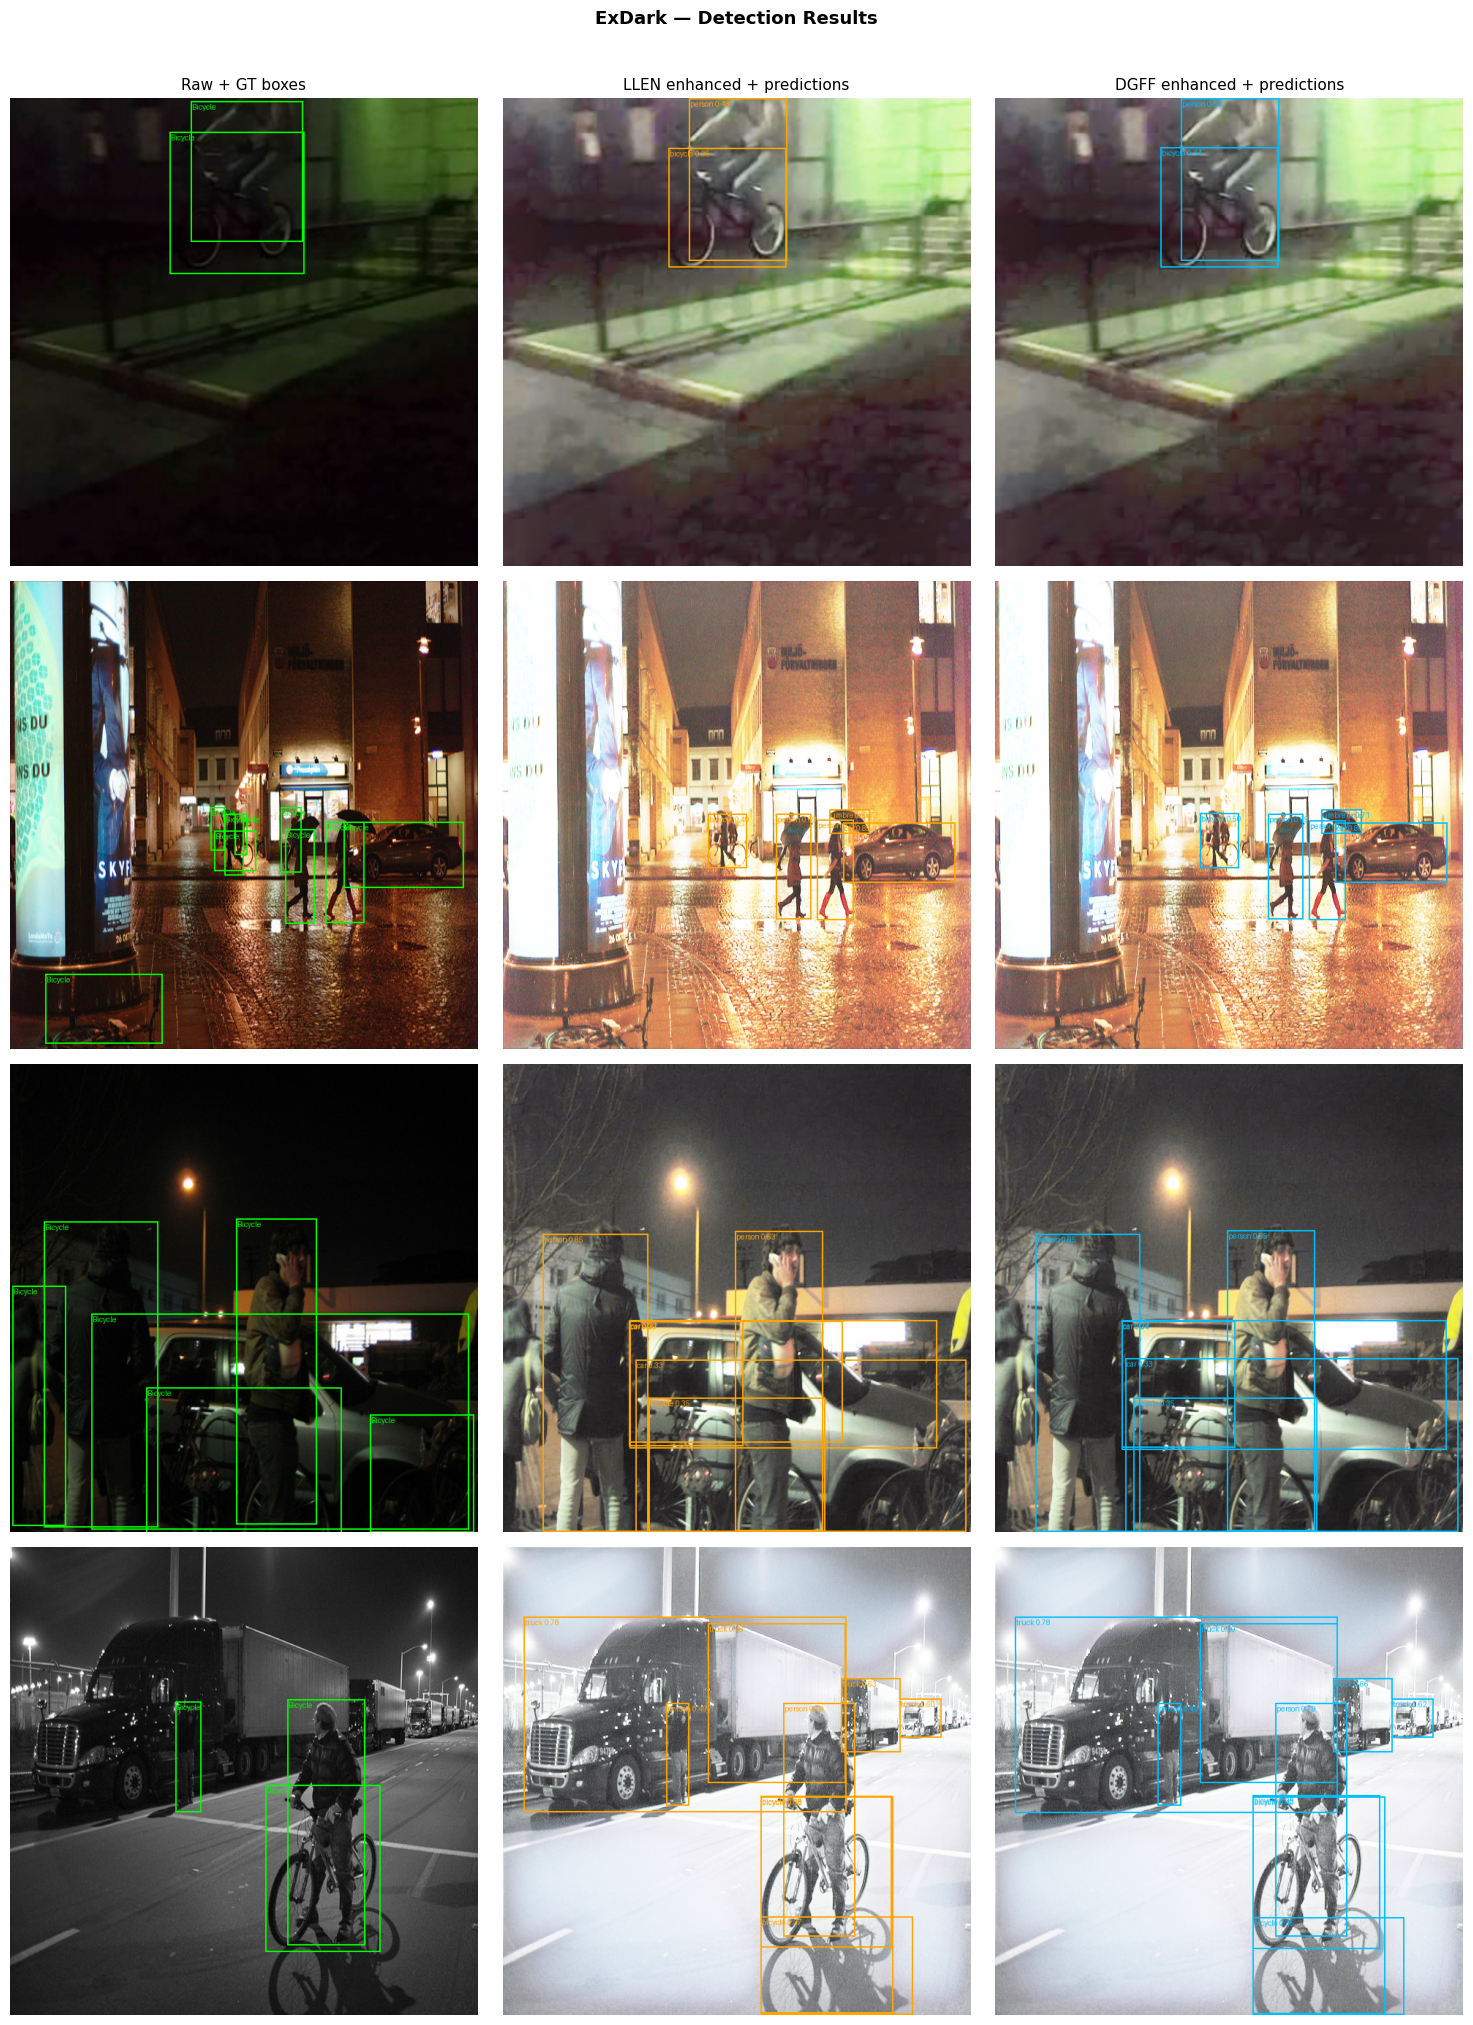

Saved → exdark_qualitative.png


In [29]:
from PIL import ImageDraw, ImageFont

COCO_CLASSES = [
    'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light',
    'fire hydrant', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
    'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee',
    'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard',
    'tennis racket', 'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple',
    'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch',
    'potted plant', 'bed', 'dining table', 'toilet', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone',
    'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase', 'scissors', 'teddy bear',
    'hair drier', 'toothbrush'
]

def draw_boxes(img_tensor, label_path, color='lime', width=2):
    """Draw YOLO-format ground-truth or predicted boxes onto a PIL image."""
    img = T.ToPILImage()(img_tensor.cpu().clamp(0,1))
    W, H = img.size
    draw = ImageDraw.Draw(img)

    lbl = Path(label_path)
    if lbl.exists():
        for line in lbl.read_text().splitlines():
            parts = line.strip().split()
            if len(parts) < 5: continue
            cls_id, cx, cy, w, h = int(parts[0]), *map(float, parts[1:5])
            x1 = int((cx - w/2) * W); y1 = int((cy - h/2) * H)
            x2 = int((cx + w/2) * W); y2 = int((cy + h/2) * H)
            draw.rectangle([x1, y1, x2, y2], outline=color, width=width)
            draw.text((x1+2, y1+2), EXDARK_CLASSES[cls_id], fill=color)
    return img


def run_yolo_predict(img_tensor_batch, device=DEVICE):
    """Run YOLOv8 inference, return list of (boxes, scores, cls_ids) per image."""
    detector = YOLO(CFG['yolo_weights'])
    results_list = []
    for img_t in img_tensor_batch:
        img_np = (img_t.cpu().permute(1,2,0).numpy() * 255).astype(np.uint8)
        res    = detector.predict(img_np, imgsz=640, conf=0.25,
                                  device=str(device), verbose=False)
        results_list.append(res[0])
    return results_list


def draw_predictions(img_tensor, yolo_result, color='red', width=2):
    img = T.ToPILImage()(img_tensor.cpu().clamp(0,1))
    draw = ImageDraw.Draw(img)
    if yolo_result.boxes is not None:
        for box in yolo_result.boxes:
            x1,y1,x2,y2 = map(int, box.xyxy[0].tolist())
            cls_id       = int(box.cls[0])
            conf         = float(box.conf[0])
            label = f"{COCO_CLASSES[cls_id]} {conf:.2f}" if cls_id < len(COCO_CLASSES) else f"class_{cls_id} {conf:.2f}"
            draw.rectangle([x1,y1,x2,y2], outline=color, width=width)
            draw.text((x1+2, y1+2), label, fill=color)
    return img

# ── Visualise N_SHOW test images ──────────────────────────────────────────────
N_SHOW = 4
llen.eval(); dgff.eval()

fig, axes = plt.subplots(N_SHOW, 3, figsize=(15, 5 * N_SHOW))
col_titles = ['Raw + GT boxes', 'LLEN enhanced + predictions', 'DGFF enhanced + predictions']

with torch.no_grad():
    for row, (imgs, lbl_paths, img_paths) in enumerate(exdark_test_loader):
        if row >= N_SHOW: break
        img = imgs[0:1].to(DEVICE)

        # Three versions of this image
        raw_img     = imgs[0]
        llen_img    = llen(img).squeeze(0)
        p4, p5      = dgff(llen(img))
        dgff_img    = llen(img, dgff_p5=p5, dgff_p4=p4).squeeze(0)

        # YOLOv8 predictions on LLEN and DGFF enhanced
        pred_llen = run_yolo_predict([llen_img])[0]
        pred_dgff = run_yolo_predict([dgff_img])[0]

        panels = [
            draw_boxes(raw_img,  lbl_paths[0], color='lime'),
            draw_predictions(llen_img, pred_llen, color='orange'),
            draw_predictions(dgff_img, pred_dgff, color='deepskyblue'),
        ]

        for col, (panel, title) in enumerate(zip(panels, col_titles)):
            axes[row, col].imshow(panel)
            axes[row, col].axis('off')
            if row == 0:
                axes[row, col].set_title(title, fontsize=11)

plt.suptitle('ExDark — Detection Results', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('exdark_qualitative.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved → exdark_qualitative.png")
